# Day 8 — EDA: Wholesale Customers

Разведочный анализ данных оптовых клиентов (UCI Wholesale customers).

**План:**
1. Сколько объектов и признаков
2. Масштабы признаков
3. Пропуски
4. Выбросы
5. Распределения
6. Матрица корреляций
7. Приведение к одному масштабу (`StandardScaler`)
8. Одна находка, которая удивила

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 1. Сколько объектов и признаков

`Channel` (1 = Horeca/отель-ресторан-кафе, 2 = Retail) и `Region` (1 = Lisbon, 2 = Oporto, 3 = Other) — категориальные. Остальные 6 — годовые траты по товарным категориям (в условных денежных единицах).

In [2]:
print(f"Объектов (строк): {df.shape[0]}")
print(f"Признаков (столбцов): {df.shape[1]}")
print()
df.info()

Объектов (строк): 440
Признаков (столбцов): 8

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [3]:
# Разделим признаки на категориальные и числовые (траты)
cat_cols = ["Channel", "Region"]
num_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]

print("Категориальные:", cat_cols)
print("Числовые (траты):", num_cols)
print()
for c in cat_cols:
    print(f"{c}: {df[c].value_counts().to_dict()}")

Категориальные: ['Channel', 'Region']
Числовые (траты): ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

Channel: {1: 298, 2: 142}
Region: {3: 316, 1: 77, 2: 47}


## 2. Масштабы признаков

Смотрим `describe()` — диапазоны (min/max), среднее и стандартное отклонение.

In [ ]:
df[num_cols].describe().T

In [4]:
# Наглядно: размах каждого признака (min, max, среднее, std)
scale_summary = pd.DataFrame({
    "min": df[num_cols].min(),
    "max": df[num_cols].max(),
    "mean": df[num_cols].mean(),
    "std": df[num_cols].std(),
})
scale_summary["max/min_ratio"] = scale_summary["max"] / scale_summary["min"].replace(0, np.nan)
scale_summary

,min,max,mean,std,max/min_ratio
Fresh,3,112151,"12,000.30","12,647.33","37,383.67"
Milk,55,73498,"5,796.27","7,380.38","1,336.33"
Grocery,3,92780,"7,951.28","9,503.16","30,926.67"
Frozen,25,60869,"3,071.93","4,854.67","2,434.76"
Detergents_Paper,3,40827,"2,881.49","4,767.85","13,609.00"
Delicassen,3,47943,"1,524.87","2,820.11","15,981.00"


**Вывод:** признаки в очень разных масштабах. Например, среднее по `Fresh` ≈ 12 000, а по `Delicassen` ≈ 1 500. Максимумы доходят до ~112 000 (`Fresh`) и ~93 000 (`Grocery`). Стандартные отклонения отличаются на порядок → масштабирование обязательно.

## 3. Пропуски

In [5]:
missing = df.isnull().sum()
print("Пропусков по столбцам:")
print(missing)
print(f"\nВсего пропусков: {missing.sum()}")
print(f"Дубликатов строк: {df.duplicated().sum()}")

Пропусков по столбцам:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Всего пропусков: 0
Дубликатов строк: 0


## 4. Выбросы

Оцениваем по правилу IQR: значение считается выбросом, если оно вне `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.

In [6]:
def count_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < low) | (s > high)).sum()

outliers = pd.DataFrame({
    "n_outliers": df[num_cols].apply(count_outliers),
})
outliers["pct"] = (outliers["n_outliers"] / len(df) * 100).round(1)
outliers.sort_values("n_outliers", ascending=False)

,n_outliers,pct
Frozen,43,9.80
Detergents_Paper,30,6.80
Milk,28,6.40
Delicassen,27,6.10
Grocery,24,5.50
Fresh,20,4.50


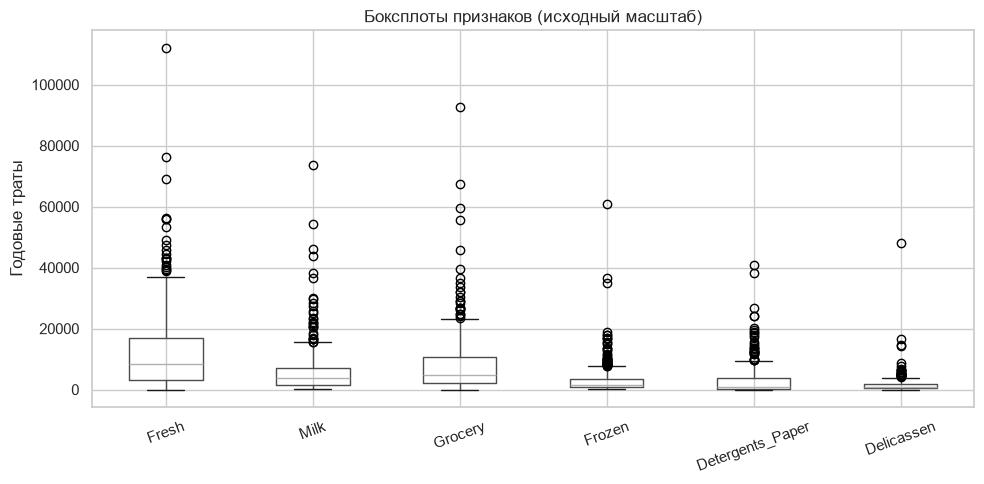

In [7]:
# Боксплоты — видно тяжёлые правые хвосты
fig, ax = plt.subplots(figsize=(10, 5))
df[num_cols].boxplot(ax=ax)
ax.set_title("Боксплоты признаков (исходный масштаб)")
ax.set_ylabel("Годовые траты")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5. Распределения

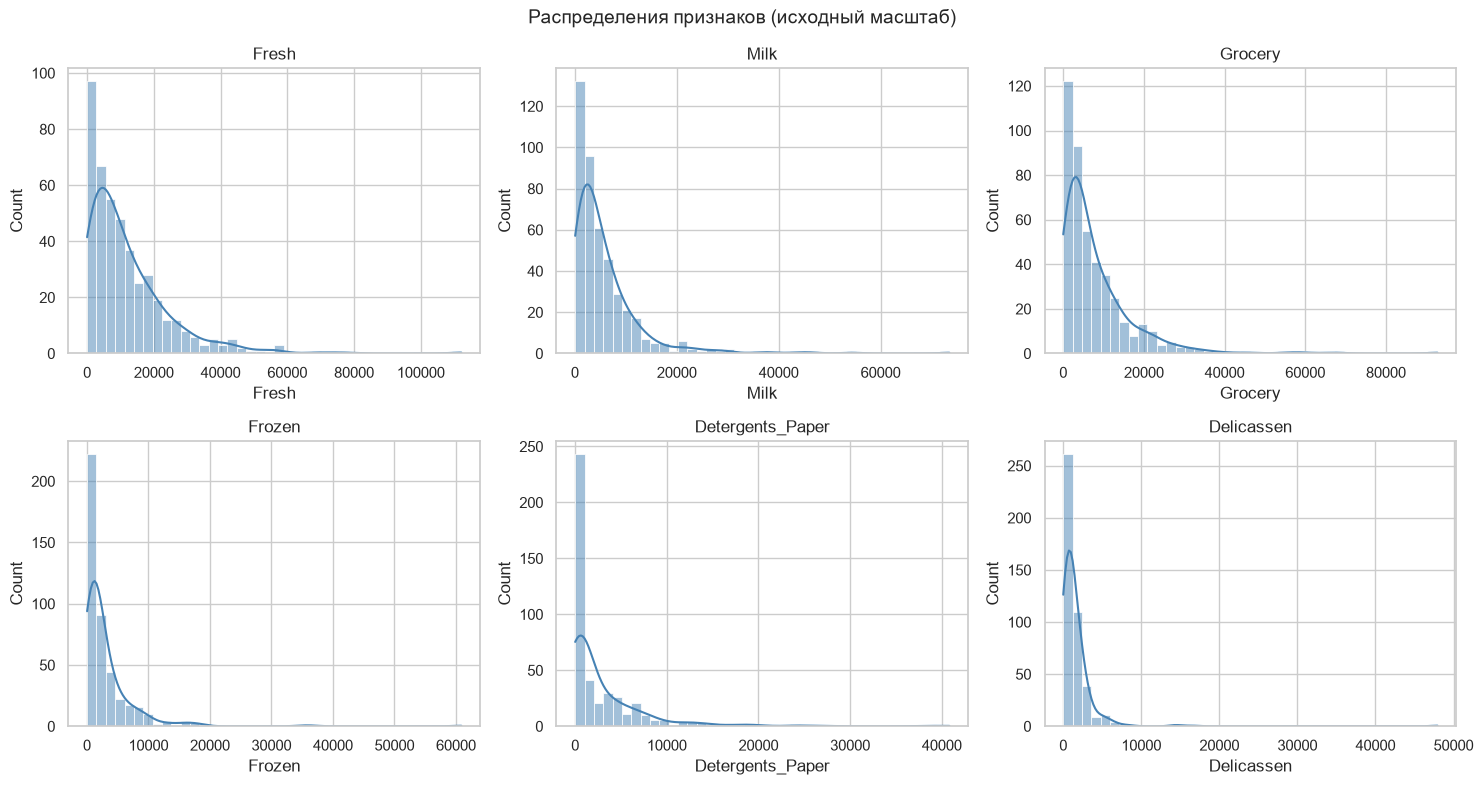

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
fig.suptitle("Распределения признаков (исходный масштаб)", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Распределения сильно скошены вправо — посмотрим коэффициент асимметрии (skewness)
df[num_cols].skew().sort_values(ascending=False)

Delicassen         11.15
Frozen              5.91
Milk                4.05
Detergents_Paper    3.63
Grocery             3.59
Fresh               2.56
dtype: float64

## 6. Матрица корреляций

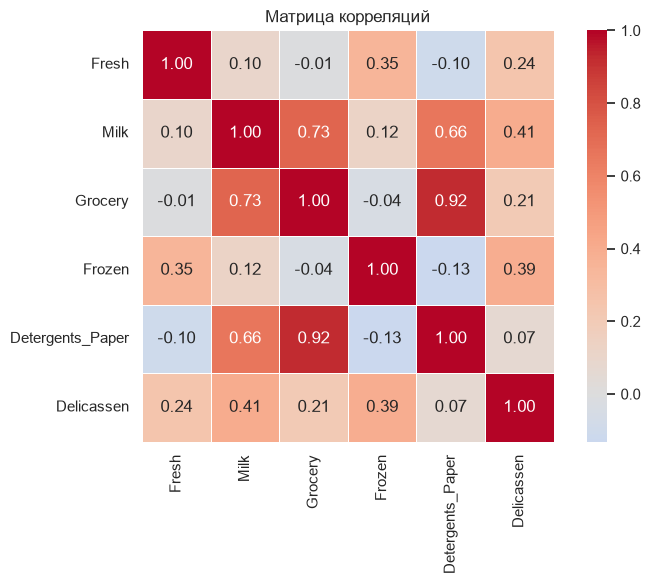

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.00,0.10,-0.01,0.35,-0.10,0.24
Milk,0.10,1.00,0.73,0.12,0.66,0.41
Grocery,-0.01,0.73,1.00,-0.04,0.92,0.21
Frozen,0.35,0.12,-0.04,1.00,-0.13,0.39
Detergents_Paper,-0.10,0.66,0.92,-0.13,1.00,0.07
Delicassen,0.24,0.41,0.21,0.39,0.07,1.00


In [10]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Матрица корреляций")
plt.tight_layout()
plt.show()

corr

## 7. Приведение к одному масштабу (`StandardScaler`)

Признаки в разных масштабах → стандартизируем: каждый признак приводим к среднему 0 и стандартному отклонению 1.

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])
df_scaled = pd.DataFrame(X_scaled, columns=num_cols)

print("После StandardScaler:")
print("\nСредние (≈ 0):")
print(df_scaled.mean().round(4))
print("\nСтанд. отклонения (≈ 1):")
print(df_scaled.std().round(4))
df_scaled.head()

После StandardScaler:

Средние (≈ 0):
Fresh              -0.00
Milk                0.00
Grocery            -0.00
Frozen              0.00
Detergents_Paper    0.00
Delicassen         -0.00
dtype: float64

Станд. отклонения (≈ 1):
Fresh              1.00
Milk               1.00
Grocery            1.00
Frozen             1.00
Detergents_Paper   1.00
Delicassen         1.00
dtype: float64


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.05,0.52,-0.04,-0.59,-0.04,-0.07
1,-0.39,0.54,0.17,-0.27,0.09,0.09
2,-0.45,0.41,-0.03,-0.14,0.13,2.24
3,0.10,-0.62,-0.39,0.69,-0.50,0.09
4,0.84,-0.05,-0.08,0.17,-0.23,1.30


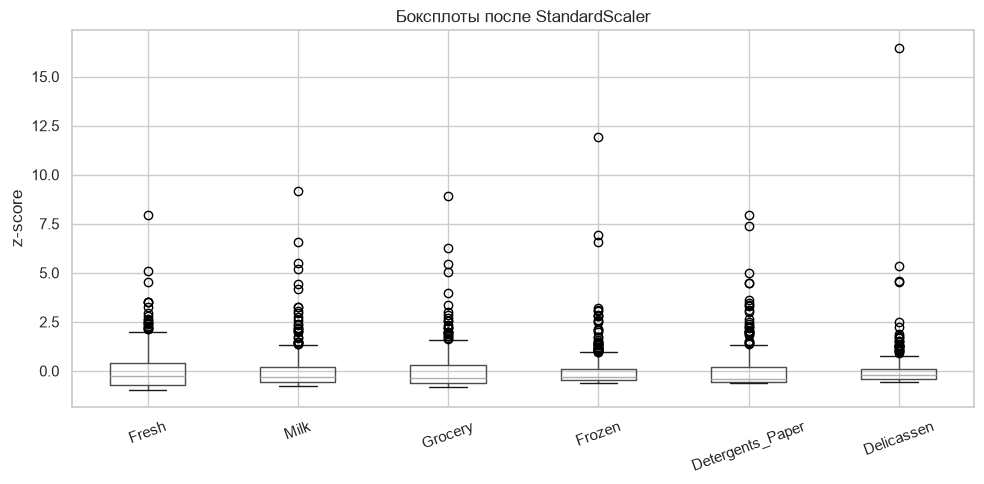

In [12]:
# Боксплоты после масштабирования — теперь признаки в сопоставимом диапазоне
fig, ax = plt.subplots(figsize=(10, 5))
df_scaled.boxplot(ax=ax)
ax.set_title("Боксплоты после StandardScaler")
ax.set_ylabel("z-score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 8. Находка, которая удивила

**`Grocery` и `Detergents_Paper` коррелируют почти на 0.92** — это самая сильная связь в данных, заметно сильнее интуитивно ожидаемой пары `Grocery`–`Milk` (~0.73).

Удивительно, что моющие средства/бумага и бакалея ведут себя почти как один признак: клиенты, закупающие много бакалеи, почти всегда закупают и моющие средства в той же пропорции. Скорее всего это **ритейл-сегмент** (`Channel = 2`, супермаркеты), где обе категории идут «в одной корзине». Для моделирования это сигнал мультиколлинеарности — две переменные несут во многом одну и ту же информацию.

Дополнительно удивило, насколько данные «тяжелохвостые»: при медианах в несколько тысяч встречаются клиенты с тратами 80–112 тысяч — отдельные оптовики на порядок крупнее типичного клиента, поэтому масштабирование и/или лог-преобразование действительно необходимы.

## 9. KMeans: сколько кластеров k?

k не угадываем. Перебираем k от 2 до 10 на **масштабированных** данных (`X_scaled`) и смотрим два критерия:
- **метод локтя** — `inertia` (сумма квадратов внутрикластерных расстояний) от k; ищем «излом»;
- **коэффициент силуэта** — насколько кластеры плотные и разделённые (выше = лучше).

Затем проверяем соседние k, чтобы выбор не был случайным пиком.

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Перебираем k и считаем inertia (для локтя) и силуэт (на масштабированных данных)
K_RANGE = range(2, 11)
rows = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
    })

scores = pd.DataFrame(rows)
scores

,k,inertia,silhouette
0,2,"1,956.12",0.55
1,3,"1,608.43",0.55
2,4,"1,317.84",0.35
3,5,"1,058.77",0.37
4,6,915.74,0.38
5,7,825.40,0.33
6,8,737.39,0.32
7,9,661.45,0.31
8,10,605.92,0.31


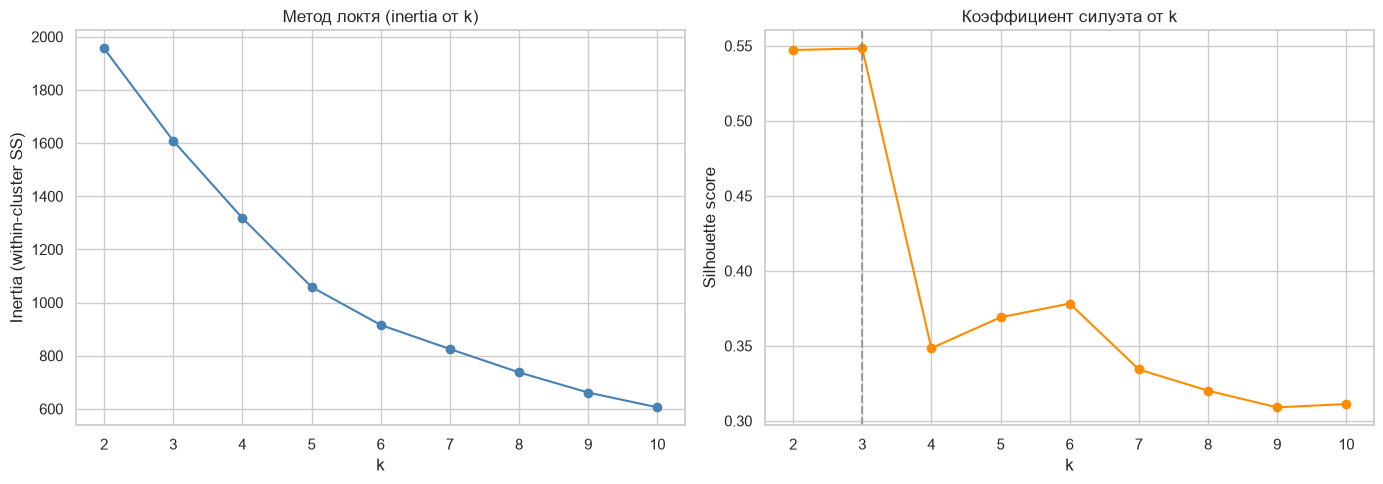

Максимум силуэта при k = 3


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Метод локтя
axes[0].plot(scores["k"], scores["inertia"], "o-", color="steelblue")
axes[0].set_title("Метод локтя (inertia от k)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (within-cluster SS)")
axes[0].set_xticks(K_RANGE)

# Силуэт
axes[1].plot(scores["k"], scores["silhouette"], "o-", color="darkorange")
best_k = scores.loc[scores["silhouette"].idxmax(), "k"]
axes[1].axvline(best_k, ls="--", color="gray", alpha=0.7)
axes[1].set_title("Коэффициент силуэта от k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_xticks(K_RANGE)

plt.tight_layout()
plt.show()

print(f"Максимум силуэта при k = {int(best_k)}")

### Итог по выбору k

- **Силуэт** максимален при **k = 3** (≈ 0.548), но k = 2 практически вровень (≈ 0.547), а на k = 4 резко падает до ≈ 0.35 и дальше не восстанавливается — «хорошая» структура есть только при 2–3 кластерах.
- **Локоть** инерции сгибается на k = 3: падение 1956 → 1608 → 1318 крутое, а после k = 3 кривая выполаживается.
- **Проверка соседей (не верим первому k на слово):** k = 2 даёт почти такой же силуэт, но более грубое деление; k = 4 — заметная потеря качества → переусложнение. Оба соседа подтверждают, что k = 3 не случайный пик.

**Выбираем k = 3** (силуэт на максимуме, локоть на сгибе). Но разрыв с k = 2 — всего ~0.001, поэтому ниже смотрим, *что* реально получилось в кластерах, прежде чем доверять этому выбору.

In [16]:
k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

# Размеры кластеров
print("Размеры кластеров:")
print(pd.Series(labels).value_counts().sort_index().to_string())

# Как кластеры соотносятся с каналом продаж (его модель не видела)
print("\nКластер x Channel (1=Horeca, 2=Retail):")
print(pd.crosstab(labels, df["Channel"]))

# Средние траты по кластерам в ИСХОДНОМ масштабе (интерпретация)
profile = df[num_cols].groupby(labels).mean().round(0)
profile.index.name = "cluster"
print("\nСредние траты по кластерам (исходный масштаб):")
profile

Размеры кластеров:
0     45
1    393
2      2

Кластер x Channel (1=Horeca, 2=Retail):
Channel    1   2
row_0           
0          1  44
1        295  98
2          2   0

Средние траты по кластерам (исходный масштаб):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,"10,441.00","19,386.00","28,656.00","2,190.00","13,328.00","2,374.00"
1,"12,063.00","4,115.00","5,535.00","2,941.00","1,696.00","1,299.00"
2,"34,782.00","30,367.00","16,898.00","48,702.00",756.00,"26,776.00"


### Что внутри кластеров (при k = 3)

Фактические размеры кластеров оказались **очень неравными: ≈ 45 / 393 / 2**. По средним тратам (исходный масштаб):

- **Кластер ~45 объектов** — высокие `Grocery` / `Milk` / `Detergents_Paper`. Это **ритейл-сегмент**: почти все попавшие сюда клиенты имеют `Channel = 2` (супермаркеты), хотя канал модель не видела. Ровно та связка `Grocery`–`Detergents_Paper`, что удивила в EDA.
- **Кластер ~393 объекта** — большой «общий» сегмент с умеренными тратами и доминированием `Fresh`; преимущественно **Horeca** (`Channel = 1`).
- **Кластер из ~2 объектов** — это клиенты-**выбросы** с экстремальными тратами (огромные `Frozen` / `Delicassen` / `Fresh`).

**Честный вывод:** высокий силуэт при k = 3 во многом держится на том, что 1–2 экстремальных клиента отделяются в крошечный кластер, а полезное деление по сути бинарное — ритейл против Horeca. Это прямое следствие тяжёлых правых хвостов из EDA: выбросы перетягивают на себя центроиды. Для более сбалансированной сегментации логично сначала применить лог-преобразование или отсечь выбросы — тогда осмысленным может стать и k = 2.

## 10. Кластер как новая (сконструированная) метка

Номера кластеров KMeans — это **новая целевая метка, которой не было в исходных данных**: мы её сконструировали сами. Добавляем её отдельным столбцом `cluster` и даём кластерам **человеческие имена** по их средним признакам — так, чтобы имя объясняло, чем группа отличается от остальных:

| cluster | Имя | Чем отличается (по средним тратам) |
|---|---|---|
| 0 | **Ритейл: бакалея, молоко и моющие** | Самые высокие `Grocery`, `Milk`, `Detergents_Paper`; ~98% клиентов — `Channel = 2` (супермаркеты) |
| 1 | **Horeca: ставка на Fresh, скромный остальной чек** | Доминирует `Fresh`, остальные категории низкие; в основном `Channel = 1` (рестораны/кафе) |
| 2 | **Экстремальные оптовики (выбросы)** | Аномально большие `Frozen`, `Delicassen`, `Fresh`; всего ~2 клиента, на порядок крупнее прочих |

Имена опираются на таблицу средних `profile` из предыдущего шага, а не на абстрактные «0/1/2».

In [17]:
# Имена даём по средним тратам кластеров (см. profile выше), а не "0/1/2".
# KMeans с фиксированным random_state=42 детерминирован, поэтому нумерация стабильна:
#   0 -> высокие Grocery/Milk/Detergents_Paper, почти все Channel=2  -> ритейл
#   1 -> упор на Fresh, скромные остальные категории, в осн. Channel=1 -> Horeca
#   2 -> экстремальные Frozen/Delicassen/Fresh, всего ~2 клиента      -> выбросы
cluster_names = {
    0: "Ритейл: бакалея, молоко и моющие",
    1: "Horeca: ставка на Fresh, скромный остальной чек",
    2: "Экстремальные оптовики (выбросы)",
}

# Сконструированная метка -> отдельные столбцы таблицы
df["cluster"] = labels
df["cluster_name"] = df["cluster"].map(cluster_names)

print("Размеры сегментов:")
print(df["cluster_name"].value_counts().to_string())

df[["Channel", "Region", *num_cols, "cluster", "cluster_name"]].head(10)

Размеры сегментов:
cluster_name
Horeca: ставка на Fresh, скромный остальной чек    393
Ритейл: бакалея, молоко и моющие                    45
Экстремальные оптовики (выбросы)                     2


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster,cluster_name
0,2,3,12669,9656,7561,214,2674,1338,1,"Horeca: ставка на Fresh, скромный остальной чек"
1,2,3,7057,9810,9568,1762,3293,1776,1,"Horeca: ставка на Fresh, скромный остальной чек"
2,2,3,6353,8808,7684,2405,3516,7844,1,"Horeca: ставка на Fresh, скромный остальной чек"
3,1,3,13265,1196,4221,6404,507,1788,1,"Horeca: ставка на Fresh, скромный остальной чек"
4,2,3,22615,5410,7198,3915,1777,5185,1,"Horeca: ставка на Fresh, скромный остальной чек"
5,2,3,9413,8259,5126,666,1795,1451,1,"Horeca: ставка на Fresh, скромный остальной чек"
6,2,3,12126,3199,6975,480,3140,545,1,"Horeca: ставка на Fresh, скромный остальной чек"
7,2,3,7579,4956,9426,1669,3321,2566,1,"Horeca: ставка на Fresh, скромный остальной чек"
8,1,3,5963,3648,6192,425,1716,750,1,"Horeca: ставка на Fresh, скромный остальной чек"
9,2,3,6006,11093,18881,1159,7425,2098,0,"Ритейл: бакалея, молоко и моющие"


## 11. PCA: проекция на 2 компоненты

Сжимаем 6 масштабированных признаков до **2 главных компонент** и рисуем клиентов на плоскости, раскрашивая по сконструированной метке `cluster_name`. Смотрим: отделяются ли сегменты визуально или налезают друг на друга. И обязательно фиксируем, **какую долю дисперсии** удержали 2 компоненты — если мало, плоская картинка обманчива.

PC1 удерживает 44.1% дисперсии
PC2 удерживает 28.4% дисперсии
Вместе PC1+PC2: 72.5%


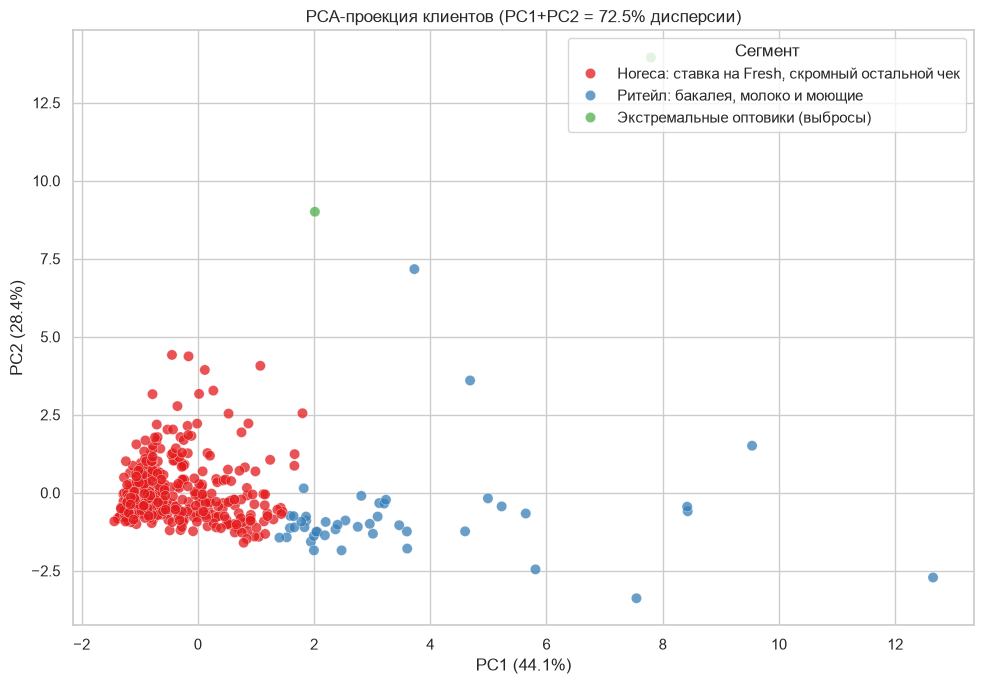

In [18]:
from sklearn.decomposition import PCA

# Сжимаем масштабированные данные до 2 компонент
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
print(f"PC1 удерживает {evr[0]:.1%} дисперсии")
print(f"PC2 удерживает {evr[1]:.1%} дисперсии")
print(f"Вместе PC1+PC2: {evr.sum():.1%}")

pca_df = pd.DataFrame(coords, columns=["PC1", "PC2"])
pca_df["cluster_name"] = df["cluster_name"].values

# Объекты на плоскости, цвет = сконструированная метка
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster_name",
                palette="Set1", s=55, alpha=0.75, edgecolor="white",
                linewidth=0.3, ax=ax)
ax.set_title(f"PCA-проекция клиентов (PC1+PC2 = {evr.sum():.1%} дисперсии)")
ax.set_xlabel(f"PC1 ({evr[0]:.1%})")
ax.set_ylabel(f"PC2 ({evr[1]:.1%})")
ax.legend(title="Сегмент", loc="upper right")
plt.tight_layout()
plt.show()

### Что видно на проекции

- **Две компоненты держат ≈ 72% дисперсии** (PC1 ≈ 44%, PC2 ≈ 28%). Это умеренно много: картинка в целом репрезентативна, но ~28% структуры (4 остальные компоненты) в неё не попало — поэтому к деталям пересечений нужно относиться осторожно.
- **Ритейл** («бакалея, молоко и моющие») визуально вытягивается в отдельную область по одной из осей — этот сегмент отделяется лучше всего.
- **Horeca** — самое плотное «облако» в центре; именно оно местами **налезает** на ритейл на границе (плавный переход, а не чёткий разрыв).
- **Экстремальные выбросы** улетают в угол графика и зрительно отрываются от всех — это и раздувало силуэт при k = 3.

**Вывод про дисперсию:** 72% — не настолько мало, чтобы картинку считать обманчивой, но и не настолько много, чтобы ей полностью доверять. Часть «налезания» кластеров может быть артефактом проекции: в исходных 6 измерениях они разделены лучше, чем выглядит на плоскости. Будь удержанная доля ~40–50%, двумерная визуализация была бы прямо обманчивой — и это был бы самостоятельный вывод.

## 12. Убираем выбросы и повторяем

В EDA мы видели тяжёлые правые хвосты, а KMeans на полных данных выделил кластер всего из 2 экстремальных клиентов — выбросы искажали и кластеризацию, и силуэт. Уберём их и повторим весь путь (масштабирование → выбор k → имена → PCA), чтобы сравнить «до/после».

Удаляем по правилу **IQR с порогом 3×** (только действительно экстремальные значения): мягкий порог 1.5×IQR убрал бы ~25% выборки, что уже слишком агрессивно.

In [19]:
# Удаляем выбросы по правилу IQR. Берём 3*IQR (только ЭКСТРЕМАЛЬНЫЕ значения):
# при 1.5*IQR ушло бы 108 строк (~25% данных) — это уже не "выбросы", а четверть выборки.
def outlier_mask(d, cols, k=3.0):
    keep = pd.Series(True, index=d.index)
    for c in cols:
        q1, q3 = d[c].quantile(0.25), d[c].quantile(0.75)
        iqr = q3 - q1
        keep &= (d[c] >= q1 - k * iqr) & (d[c] <= q3 + k * iqr)
    return keep

mask = outlier_mask(df, num_cols, k=3.0)
df_clean = df[mask].reset_index(drop=True)

print(f"Было: {len(df)} строк")
print(f"Удалено выбросов (вне 3*IQR хотя бы по одному признаку): {(~mask).sum()}")
print(f"Осталось: {len(df_clean)} строк ({len(df_clean)/len(df):.1%})")

Было: 440 строк
Удалено выбросов (вне 3*IQR хотя бы по одному признаку): 38
Осталось: 402 строк (91.4%)


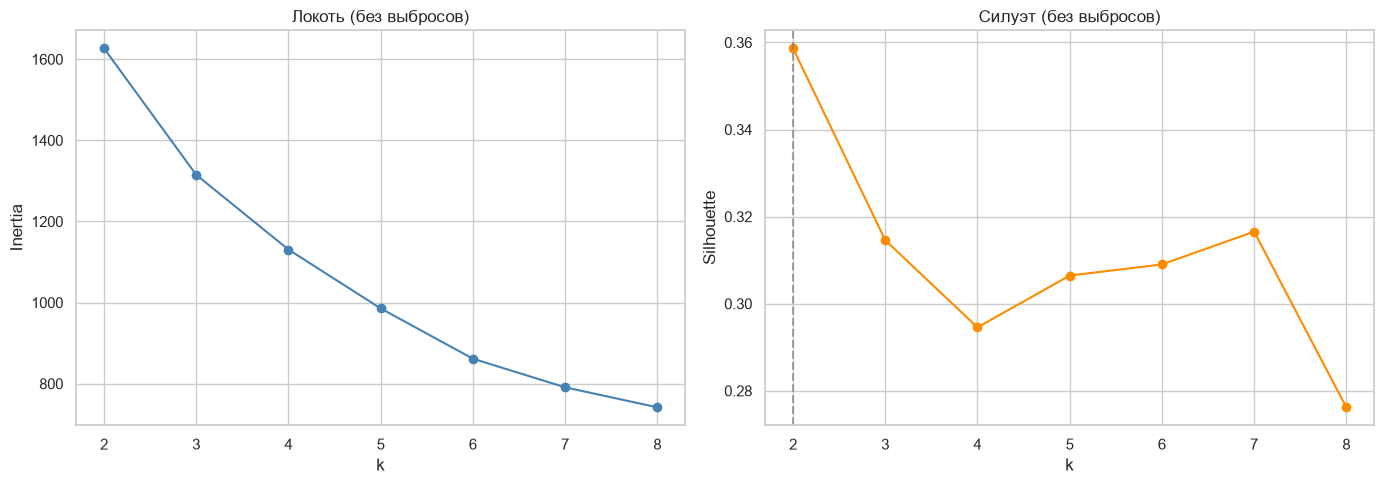

Максимум силуэта теперь при k = 2


,k,inertia,silhouette
0,2,"1,626.65",0.36
1,3,"1,314.82",0.31
2,4,"1,130.66",0.29
3,5,985.44,0.31
4,6,861.52,0.31
5,7,791.01,0.32
6,8,741.62,0.28


In [20]:
# Заново масштабируем УЖЕ очищенные данные и перебираем k
X_clean = StandardScaler().fit_transform(df_clean[num_cols])

rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_clean)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(X_clean, lbl)})
scores_clean = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(scores_clean["k"], scores_clean["inertia"], "o-", color="steelblue")
axes[0].set_title("Локоть (без выбросов)"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(scores_clean["k"], scores_clean["silhouette"], "o-", color="darkorange")
best_k_clean = int(scores_clean.loc[scores_clean["silhouette"].idxmax(), "k"])
axes[1].axvline(best_k_clean, ls="--", color="gray", alpha=0.7)
axes[1].set_title("Силуэт (без выбросов)"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

print(f"Максимум силуэта теперь при k = {best_k_clean}")
scores_clean

### Заново выбираем k на очищенных данных

После удаления выбросов **общий уровень силуэта заметно ниже** (≈ 0.36 против ≈ 0.55 раньше), и максимум теперь на **k = 2**, а не k = 3. Это важный сигнал: тот «красивый» k = 3 во многом держался на выбросах, отделявшихся в отдельный кластер. Без них честно оптимально **2 сегмента** — ровно то, что и есть в данных по смыслу (розница vs общепит).

In [21]:
# Выбираем k = 2 (максимум силуэта на очищенных данных) и заново именуем сегменты
k_clean = 2
labels_clean = KMeans(n_clusters=k_clean, random_state=42, n_init=10).fit_predict(X_clean)

print("Размеры кластеров:")
print(pd.Series(labels_clean).value_counts().sort_index().to_string())
print("\nКластер x Channel (1=Horeca, 2=Retail):")
print(pd.crosstab(labels_clean, df_clean["Channel"]))

# Имена по средним тратам (нумерация стабильна при random_state=42):
#   0 -> высокие Grocery/Milk/Detergents_Paper, в осн. Channel=2 -> ритейл
#   1 -> упор на Fresh, низкие остальные, в осн. Channel=1       -> Horeca
names_clean = {
    0: "Ритейл: бакалея, молоко и моющие",
    1: "Horeca: ставка на Fresh",
}
df_clean["cluster"] = labels_clean
df_clean["cluster_name"] = df_clean["cluster"].map(names_clean)

profile_clean = df_clean[num_cols].groupby(labels_clean).mean().round(0)
profile_clean.index.name = "cluster"
print("\nСредние траты по кластерам (исходный масштаб):")
profile_clean

Размеры кластеров:
0    110
1    292

Кластер x Channel (1=Horeca, 2=Retail):
Channel    1   2
row_0           
0         15  95
1        263  29

Средние траты по кластерам (исходный масштаб):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,"6,838.00","9,802.00","14,904.00","1,451.00","6,197.00","1,583.00"
1,"12,599.00","2,799.00","3,545.00","2,695.00",813.00,"1,047.00"


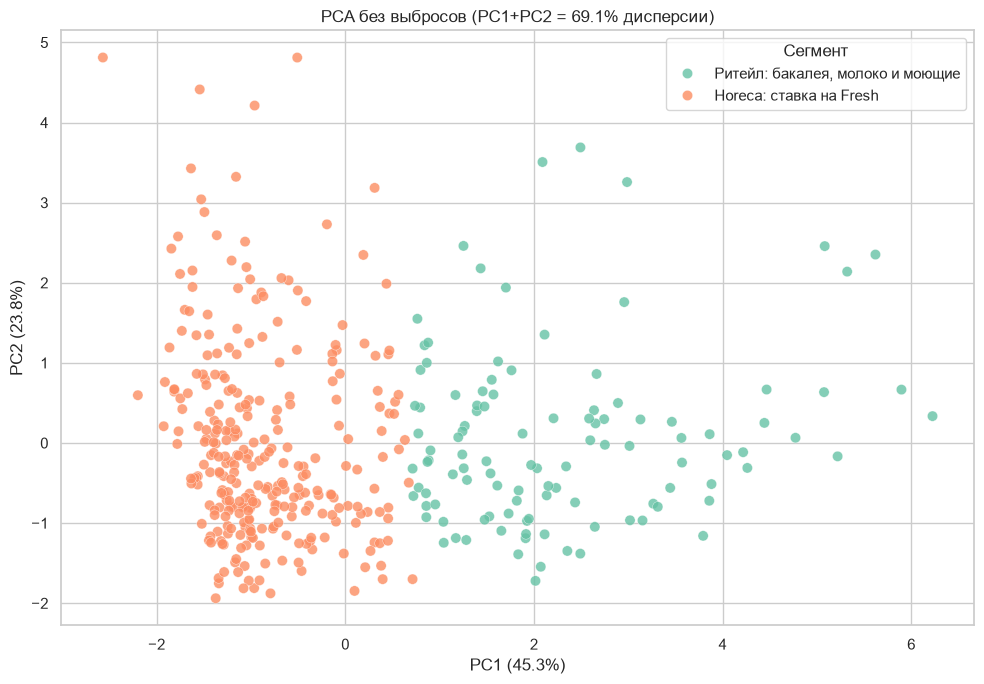

PC1+PC2 удержали 69.1% дисперсии


In [22]:
# PCA-проекция очищенных данных, цвет = новый сегмент
pca_c = PCA(n_components=2, random_state=42)
coords_c = pca_c.fit_transform(X_clean)
evr_c = pca_c.explained_variance_ratio_

pca_c_df = pd.DataFrame(coords_c, columns=["PC1", "PC2"])
pca_c_df["cluster_name"] = df_clean["cluster_name"].values

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=pca_c_df, x="PC1", y="PC2", hue="cluster_name",
                palette="Set2", s=55, alpha=0.8, edgecolor="white",
                linewidth=0.3, ax=ax)
ax.set_title(f"PCA без выбросов (PC1+PC2 = {evr_c.sum():.1%} дисперсии)")
ax.set_xlabel(f"PC1 ({evr_c[0]:.1%})")
ax.set_ylabel(f"PC2 ({evr_c[1]:.1%})")
ax.legend(title="Сегмент", loc="upper right")
plt.tight_layout()
plt.show()

print(f"PC1+PC2 удержали {evr_c.sum():.1%} дисперсии")

### Итог: до и после удаления выбросов

| | С выбросами (440) | Без выбросов (402) |
|---|---|---|
| Лучший k | 3 | **2** |
| Силуэт при лучшем k | ≈ 0.55 | ≈ 0.36 |
| Размеры кластеров | 45 / 393 / **2** | 110 / 292 |
| Третий кластер | 2 клиента-выброса | исчез |
| Дисперсия в PC1+PC2 | ≈ 72% | ≈ 69% |

**Главный вывод (контринтуитивный):** после удаления выбросов силуэт **упал** (0.55 → 0.36). Это значит, что высокая «чёткость» кластеров раньше во многом создавалась самими выбросами — пара экстремальных клиентов сидела далеко от всех и искусственно завышала метрику. Убрав их, мы получили **более честную** картину: оптимально 2 сегмента, и они *честно* пересекаются, потому что граница «розница ↔ общепит» в реальности плавная.

При этом сегментация стала **полезнее**: вместо «45 / 393 / 2» — сбалансированное **110 / 292**, где кластеры по-прежнему совпадают с реальным каналом (`Channel`), который модель не видела. Высокий силуэт ≠ хорошая кластеризация: иногда он просто отражает наличие выбросов.